## Simulación en MuJoCo (GPU).
Requiere cambio de entorno a GPU. Dado que el uso de GPU se limita por tiempo, no lo active hasta que sea necesario para visualizar.

Revisar <https://docs.hello-robot.com/0.3/stretch-mujoco/docs/getting_started/> para ver uso solo con CPU en colab (más lento)

### Librerías necesarias para la simulación en MuJoCo.


In [1]:
# Other imports and helper functions
from IPython.display import clear_output
from typing import Callable, Optional, Union, List
# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media

''' AGREGA TUS LIBRERIAS '''
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.linalg
import numpy as np
!pip install loop_rate_limiters
from loop_rate_limiters import RateLimiter

#limpia el mucho texto
clear_output()

### Instalación de mink y mujoco

In [2]:
!pip install mujoco
!pip install mink

# Set up GPU rendering.
from google.colab import files
import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 40.4 MB/s eta 0:00:00
Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


### Clonación de repo

In [3]:
#Clonacion del repositorio para los modelos
print('Getting MuJoCo model XML description from GitHub:')
!git clone https://github.com/LEMUR-DIMEC/ME6030_tutorials

Getting MuJoCo model XML description from GitHub:
Cloning into 'ME6030_tutorials'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 57 (delta 12), reused 54 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 1.50 MiB | 16.47 MiB/s, done.
Resolving deltas: 100% (12/12), done.


## Modelo simulado: Perrito robot arm


### Animación del modelo

In [4]:
%cd
%cd /content/ME6030_tutorials/perrito_robot_arm/model
with open('scene.xml', 'r') as f:
  xml = f.read()
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model,480,640)

/root
/content/ME6030_tutorials/perrito_robot_arm/model


In [12]:
import mink
configuration = mink.Configuration(model)
tasks = [
    end_effector_task := mink.FrameTask(
        frame_name="attachment_site",
        frame_type="site",
        position_cost=1.0,
        orientation_cost=1.0,
        lm_damping=1.0,
    ),
]
# Enable collision avoidance between the following geoms:
collision_pairs = []

limits = [
    mink.ConfigurationLimit(model=model),
    mink.CollisionAvoidanceLimit(model=model, geom_pairs=collision_pairs),
]

max_velocities = {
    "joint1": np.pi,
    "joint2": np.pi,
    "joint3": np.pi,
    "joint4": np.pi,
    "joint5": np.pi,
    "joint6": np.pi,
}
velocity_limit = mink.VelocityLimit(model, max_velocities)
limits.append(velocity_limit)

mid = model.body("target").mocapid[0]
model = configuration.model
data = configuration.data
solver = "daqp"

DURATION  = 1   # aprox seconds
FRAMERATE = 60  # Hz
camera = mujoco.MjvCamera()
cam1= mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 1.3
camera.azimuth = -45
camera.elevation = -25
camera.orthographic=1

mujoco.mj_resetDataKeyframe(model, data, 1)

frames = []
body_positions = [] # List to store end-effector positions
rate = RateLimiter(frequency=120.0, warn=False)

# Initialize to the home keyframe.
configuration.update_from_keyframe("pick")

# Initialize the mocap target at the end-effector site.
mink.move_mocap_to_frame(model, data, "target", "attachment_site", "site")

while data.time < DURATION:
  # Update task target.
  # Append end-effector position to the list
  body_positions.append(data.xpos.copy())
  #T_wt = mink.SE3.from_mocap_name(model, data, "target")
  tar= mink.SE3.identity()
  tar.translation()[:] = np.array([0.3, 0.0, 0.3])
  end_effector_task.set_target(tar)
  # Compute velocity and integrate into the next configuration.
  vel = mink.solve_ik(
      configuration, tasks, rate.dt, solver, 1e-3, limits=limits
  )
  configuration.integrate_inplace(vel, rate.dt)
  mujoco.mj_step(model, data)
  camera.lookat = np.array([-0.05, 0.0, 0.3])
  renderer.update_scene(data, camera)
  pixels = renderer.render()
  frames.append(pixels)
  rate.sleep()

media.show_video(frames, fps=FRAMERATE)


This browser does not support the video tag.


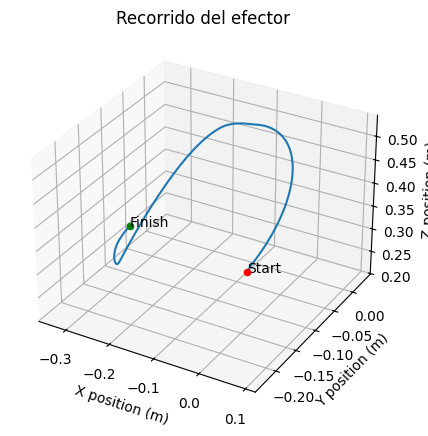

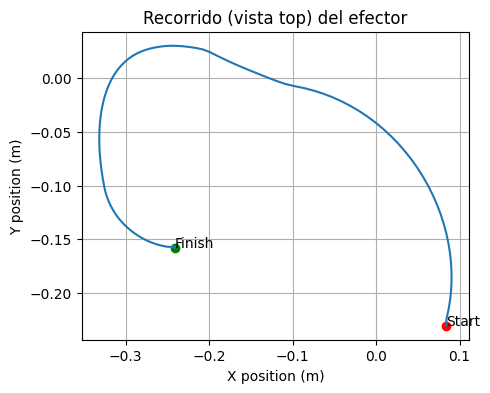

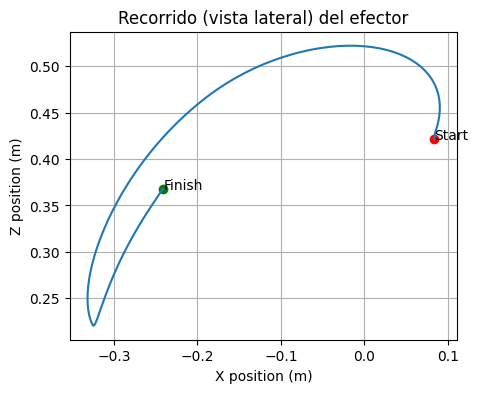

In [13]:
end_effector_positions = np.array(body_positions)
# time_steps, number_of_bodies, xyz_coordinates
num_time_steps, num_bodies, num_coordinates = end_effector_positions.shape

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(end_effector_positions[:, 4, 0], end_effector_positions[:, 4, 1], end_effector_positions[:, 4, 2])
ax.scatter(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 1], end_effector_positions[0, 4, 2], color='red')
ax.scatter(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 1], end_effector_positions[-1, 4, 2], color='green')
ax.text(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 1], end_effector_positions[0, 4, 2], 'Start')
ax.text(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 1], end_effector_positions[-1, 4, 2], 'Finish')
ax.set_xlabel('X position (m)')
ax.set_ylabel('Y position (m)')
ax.set_zlabel('Z position (m)')
ax.set_title(f'Recorrido del efector')
ax.grid(True)

#vista top XY
fig2 = plt.figure(figsize=(5, 4))
plt.plot(end_effector_positions[:, 4, 0], end_effector_positions[:, 4, 1])
plt.scatter(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 1], color='red')
plt.scatter(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 1], color='green')
plt.text(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 1], 'Start')
plt.text(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 1], 'Finish')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.grid(True)
plt.title(f'Recorrido (vista top) del efector')

#vista lateral XZ
fig3 = plt.figure(figsize=(5,4))
plt.plot(end_effector_positions[:, 4, 0], end_effector_positions[:, 4, 2])
plt.scatter(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 2], color='red')
plt.scatter(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 2], color='green')
plt.text(end_effector_positions[0, 4, 0], end_effector_positions[0, 4, 2], 'Start')
plt.text(end_effector_positions[-1, 4, 0], end_effector_positions[-1, 4, 2], 'Finish')
plt.xlabel('X position (m)')
plt.ylabel('Z position (m)')
plt.grid(True)
plt.title(f'Recorrido (vista lateral) del efector')

plt.show()

